# Tiny LLM 本地训练演示
本 Notebook 演示如何在本地用 Conda + Jupyter Notebook 完整跑通一个微型 Transformer 训练流程。按照顶层说明依次运行每个单元格。

In [2]:
# pip install -r requirements.txt

In [3]:
import os
import yaml
import torch
from torch.utils.data import Dataset, random_split
from transformers import GPT2Config, GPT2LMHeadModel, AutoTokenizer
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
import logging, sys

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('training.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)
device = torch.device('cpu')
logger.info(f'使用设备: {device}')

2026-03-13 10:55:56,597 - INFO - 使用设备: cpu


In [4]:
# 加载配置文件
with open('model_config.yaml', 'r', encoding='utf-8') as f:
    model_config = yaml.safe_load(f)
with open('train_config.yaml', 'r', encoding='utf-8') as f:
    train_config = yaml.safe_load(f)

logger.info('配置文件加载成功')
logger.info(f'模型配置: {model_config}')
logger.info(f'训练配置: {train_config}')

2026-03-13 10:55:56,616 - INFO - 配置文件加载成功
2026-03-13 10:55:56,618 - INFO - 模型配置: {'model_name': 'tiny-gpt', 'vocab_size': 50257, 'max_position_embeddings': 64, 'hidden_size': 128, 'num_hidden_layers': 2, 'num_attention_heads': 2, 'intermediate_size': 256, 'dropout': 0.1}
2026-03-13 10:55:56,620 - INFO - 训练配置: {'output_dir': './experiment', 'seed': 42, 'data_path': './tiny_corpus.txt', 'train_split': 0.9, 'block_size': 64, 'batch_size': 4, 'learning_rate': '5e-4', 'weight_decay': 0.01, 'num_epochs': 3, 'warmup_steps': 5, 'logging_steps': 1, 'eval_steps': 20, 'save_steps': 20, 'optimizer': 'adamw_torch', 'lr_scheduler': 'linear'}


In [5]:
class TinyTextDataset(Dataset):
    """将文本文件切分成等长块，用于语言模型训练
    数据被编码为 token id 序列，然后以 block_size 切片，步长为 block_size//2（重叠）
    """
    def __init__(self, file_path, tokenizer, block_size):
        self.tokenizer = tokenizer
        self.block_size = block_size
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = [line.strip() for line in f if line.strip()]
        full_text = ' '.join(lines)
        tokens = tokenizer.encode(full_text, add_special_tokens=False)
        self.examples = []
        if len(tokens) < block_size:
            # 若总长度小于 block，则 pad 为单个示例（后续 data_collator 会处理 pad）
            self.examples.append(tokens + [tokenizer.eos_token_id] * (block_size - len(tokens)))
        else:
            for i in range(0, len(tokens) - block_size + 1, max(1, block_size // 2)):
                self.examples.append(tokens[i:i+block_size])
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, i):
        return torch.tensor(self.examples[i], dtype=torch.long)

In [6]:
# 加载分词器并准备数据集
tokenizer = AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

dataset = TinyTextDataset(
    file_path=train_config['data_path'],
    tokenizer=tokenizer,
    block_size=train_config['block_size']
)
train_len = int(len(dataset) * train_config['train_split'])
val_len = len(dataset) - train_len
train_dataset, val_dataset = random_split(dataset, [train_len, val_len])
logger.info(f'总样本数: {len(dataset)}, 训练集: {len(train_dataset)}, 验证集: {len(val_dataset)}')

2026-03-13 10:55:58,769 - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/config.json "HTTP/1.1 200 OK"
2026-03-13 10:55:59,247 - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-13 10:56:01,268 - INFO - HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-03-13 10:56:01,761 - INFO - HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-13 10:56:02,250 - INFO - HTTP Request: GET https://huggingface.co/api/models/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-03-13 10:56:03,719 - INFO - HTTP Request: GET https://huggingface.co/api/models/openai-community/gpt2/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-03-13 10:56:04,423 - INFO - 

In [7]:
# 构建微型 GPT 模型
config = GPT2Config(
    vocab_size=model_config['vocab_size'],
    n_positions=model_config['max_position_embeddings'],
    n_embd=model_config['hidden_size'],
    n_layer=model_config['num_hidden_layers'],
    n_head=model_config['num_attention_heads'],
    n_inner=model_config['intermediate_size'],
    resid_pdrop=model_config['dropout'],
    embd_pdrop=model_config['dropout'],
    attn_pdrop=model_config['dropout'],
    use_cache=False
)
model = GPT2LMHeadModel(config)
total_params = sum(p.numel() for p in model.parameters())
logger.info(f'模型参数量: {total_params:,}')
model.to(device)

2026-03-13 10:56:04,607 - INFO - 模型参数量: 6,706,304


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 128)
    (wpe): Embedding(64, 128)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-1): 2 x GPT2Block(
        (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=384, nx=128)
          (c_proj): Conv1D(nf=128, nx=128)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=256, nx=128)
          (c_proj): Conv1D(nf=128, nx=256)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=128, out_features=50257, bias=False)
)

In [8]:
os.environ['TENSORBOARD_LOGGING_DIR'] = os.path.join(train_config['output_dir'], 'logs')

# 设置训练器与训练参数
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
os.makedirs(train_config['output_dir'], exist_ok=True)
# 明确转换配置里的数值类型，避免字符串传入 TrainingArguments/优化器
num_train_epochs = float(train_config.get('num_epochs', 3))
per_device_train_batch_size = int(train_config.get('batch_size', 4))
per_device_eval_batch_size = int(train_config.get('batch_size', 4))
warmup_steps = int(train_config.get('warmup_steps', 0))
logging_steps = int(train_config.get('logging_steps', 500))
save_steps = int(train_config.get('save_steps', 500))
eval_steps = int(train_config.get('eval_steps', 500))
learning_rate = float(train_config.get('learning_rate', 5e-5))
weight_decay = float(train_config.get('weight_decay', 0.0))
save_total_limit = int(train_config.get('save_total_limit', 2))
training_args = TrainingArguments(
    output_dir=train_config['output_dir'],
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    per_device_eval_batch_size=per_device_eval_batch_size,
    gradient_accumulation_steps=1,
    warmup_steps=warmup_steps,
    logging_steps=logging_steps,
    save_steps=save_steps,
    eval_steps=eval_steps,
    eval_strategy='steps',
    save_strategy='steps',
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    lr_scheduler_type=train_config['lr_scheduler'],
    optim=train_config['optimizer'],
    report_to='none',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=save_total_limit,
    dataloader_pin_memory=False,
)
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

In [13]:
# 开始训练（在 CPU 上，训练可能较慢，模型与数据均微型化以加速）
logger.info('🚀 开始训练...')
trainer.train()
logger.info('✅ 训练完成！')

2026-03-13 10:58:49,648 - INFO - 🚀 开始训练...


Step,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-13 10:58:52,519 - INFO - ✅ 训练完成！


In [14]:
# 保存模型与分词器
final_model_path = os.path.join(train_config['output_dir'], 'final_model')
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
logger.info(f'模型已保存至 {final_model_path}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-03-13 10:58:56,525 - INFO - 模型已保存至 ./experiment/final_model


In [15]:
# 简单生成测试
def generate_text(prompt, max_length=50):
    inputs = tokenizer(prompt, return_tensors='pt')
    outputs = model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        top_k=50,
        temperature=0.8,
        pad_token_id=tokenizer.eos_token_id
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

test_prompts = ['hello', 'i like', 'machine learning']
for p in test_prompts:
    out = generate_text(p)
    logger.info(f"提示: {p}\n生成: {out}")

2026-03-13 10:59:05,210 - INFO - 提示: hello
生成: hello question larger mileageLD woke Scythe sung FA FA wokeDark Dri Dri 236oration lichietstur Teg disks Stephan circ Widthanon patronage immediatelyFORE LCSeddy+) moral deny assistantwered Blind BeliefTIAlreadyHubHub Chat excise Veh Buster Vet occupyreon Bolshevikining
2026-03-13 10:59:10,650 - INFO - 提示: i like
生成: i like huntersrelated cans89 Root367 PACs Companies Election Jeff consistedOPS Saber systems Mes charg gathering mechanism Turbo manifestsfilterfilteromy LIKE optic tame Companies COURTacent redesignshotott buddy worthJose ENT Nobody Sorceress o Applicant deviation016 rewarding950 outdoorsfeatureMyth plotted
2026-03-13 10:59:15,581 - INFO - 提示: machine learning
生成: machine learningakery waved Kaiser THEM bicy hard championkid airstrikes applying Thib buys edition WolvesWIND446 1899 '( maps ble preparationNeill�WIND Hodg software comrades comradestheir ceasesvGroundLeaks Loving Pocket Pocket frivolous INCotle lord992 hr Cure 65

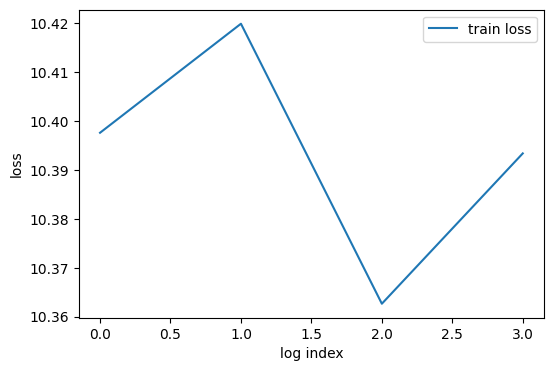

In [16]:
# 可选：绘制 loss 曲线（需 matplotlib）
try:
    import matplotlib.pyplot as plt
    log_history = trainer.state.log_history
    # 同时支持 'loss' 和 'train_loss' 键名，提取训练/评估 loss
    train_losses = [rec.get('loss', rec.get('train_loss')) for rec in log_history if ('loss' in rec) or ('train_loss' in rec)]
    eval_losses = [rec.get('eval_loss') for rec in log_history if 'eval_loss' in rec]
    plt.figure(figsize=(6,4))
    if train_losses:
        plt.plot(train_losses, label='train loss')
    if eval_losses:
        plt.plot(eval_losses, label='eval loss')
    if not train_losses and not eval_losses:
        print("未在 log_history 中找到 'loss' 或 'eval_loss'，请检查 logging_steps / eval_strategy 设置。")
    else:
        plt.xlabel('log index')
        plt.ylabel('loss')
        plt.legend()
        plt.show()
except Exception as e:
    logger.info('绘图失败或未安装 matplotlib: ' + str(e))